<a href="https://colab.research.google.com/github/jahnavi1thoom/DeepLearning/blob/main/fashion_mnist(CNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🛍 Scenario: Fashion Product Image Classifier
You are working as an AI Engineer for an e-commerce company.
The company wants to automatically classify clothing products from images into categories such as:
T-shirt
Trouser
Pullover
Dress
Coat
Sandal
Shirt
Sneaker
Bag
Ankle boot
The dataset contains 28×28 grayscale images of fashion items.
Your goal is to build a Convolutional Neural Network (CNN) that can classify these fashion products correctly.

Task 1 — Dataset Exploration
Load the Fashion-MNIST dataset and perform basic inspection.
Students must:
Load dataset using TensorFlow/Keras
Print:
Number of training images
Number of testing images
Display 10 random images with their labels
Goal:

Understand the dataset visually.
Task 2 — Data Preprocessing
Prepare the dataset for CNN training.
Students must:
Normalize pixel values (0–255 → 0–1)
Reshape images to CNN format
Expected shape:
(28, 28, 1)
Also convert labels to one-hot encoding.

Task 3 — Visualize Class Distribution
Students must:
Count number of images in each class
Plot bar chart of class distribution
Goal:

Check whether the dataset is balanced.


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Number of training images: 60000
Number of testing images: 10000
Image shape: (28, 28)


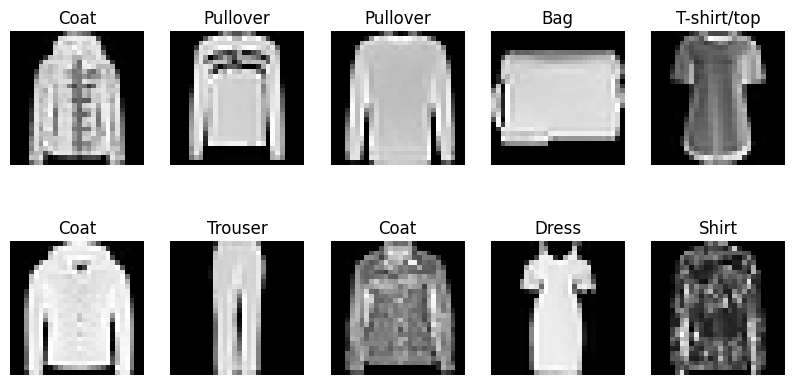

In [7]:
# Import libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load Fashion MNIST dataset
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Print dataset information
print("Number of training images:", x_train.shape[0])
print("Number of testing images:", x_test.shape[0])
print("Image shape:", x_train.shape[1:])

# Class names
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# Display 10 random images
plt.figure(figsize=(10,5))

for i in range(10):
    index = np.random.randint(0, len(x_train))
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[index], cmap='gray')
    plt.title(class_names[y_train[index]])
    plt.axis('off')

plt.show()

In [8]:
from tensorflow.keras.utils import to_categorical

# Normalize pixel values (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN (28,28 → 28,28,1)
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

print("New training shape:", x_train.shape)
print("New testing shape:", x_test.shape)

# One-hot encoding labels
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

print("Label shape after one-hot encoding:", y_train.shape)

New training shape: (60000, 28, 28, 1)
New testing shape: (10000, 28, 28, 1)
Label shape after one-hot encoding: (60000, 10)


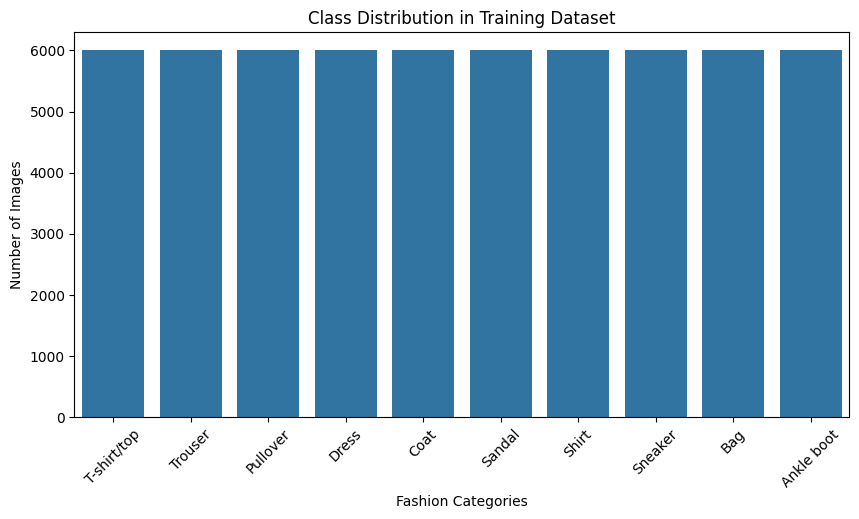

In [9]:
import seaborn as sns

# Convert labels back to integers for counting
labels = np.argmax(y_train, axis=1)

# Count number of images in each class
unique, counts = np.unique(labels, return_counts=True)

# Plot bar chart
plt.figure(figsize=(10,5))
sns.barplot(x=class_names, y=counts)

plt.title("Class Distribution in Training Dataset")
plt.xlabel("Fashion Categories")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.show()

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Build CNN model
model = Sequential()

# Input Layer + Conv Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))

# Max Pooling
model.add(MaxPooling2D(pool_size=(2,2)))

# Conv Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))

# Max Pooling
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten layer
model.add(Flatten())

# Dense layer
model.add(Dense(128, activation='relu'))

# Output layer
model.add(Dense(10, activation='softmax'))

# Show model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Compile the CNN model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [13]:
# Train the model
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9024 - loss: 0.2689 - val_accuracy: 0.8983 - val_loss: 0.2826
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9106 - loss: 0.2414 - val_accuracy: 0.8880 - val_loss: 0.3068
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9171 - loss: 0.2226 - val_accuracy: 0.8907 - val_loss: 0.3023
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9266 - loss: 0.2006 - val_accuracy: 0.8975 - val_loss: 0.2949
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9340 - loss: 0.1790 - val_accuracy: 0.9053 - val_loss: 0.2621
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9426 - loss: 0.1588 - val_accuracy: 0.9127 - val_loss: 0.2592
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9482 - loss: 0.1434 - val_accuracy: 0.9094 - val_loss: 0.2780
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9523 - loss: 0.1284 - val_accuracy: 0.

In [14]:
# Evaluate model on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9064 - loss: 0.3168
Test Loss: 0.3094731569290161
Test Accuracy: 0.9067999720573425


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


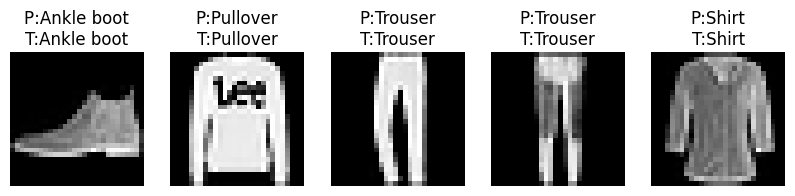

In [15]:
# Class names
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# Predict on test data
predictions = model.predict(x_test)

plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)

    # show image
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')

    # predicted label
    predicted_label = class_names[np.argmax(predictions[i])]

    # actual label
    true_label = class_names[np.argmax(y_test[i])]

    plt.title(f"P:{predicted_label}\nT:{true_label}")
    plt.axis('off')

plt.show()

In [16]:
from tensorflow.keras.layers import Dropout

model2 = Sequential()

# Conv → Conv → Pool
model2.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model2.add(Conv2D(32, (3,3), activation='relu'))
model2.add(MaxPooling2D((2,2)))

# Conv → Pool
model2.add(Conv2D(64, (3,3), activation='relu'))
model2.add(MaxPooling2D((2,2)))

# Flatten
model2.add(Flatten())

# Dense
model2.add(Dense(128, activation='relu'))

# Dropout added
model2.add(Dropout(0.5))

# Output
model2.add(Dense(10, activation='softmax'))

In [17]:
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history2 = model2.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6833 - loss: 0.8734 - val_accuracy: 0.8620 - val_loss: 0.3701
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8495 - loss: 0.4143 - val_accuracy: 0.8809 - val_loss: 0.3219
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8776 - loss: 0.3414 - val_accuracy: 0.8957 - val_loss: 0.2823
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8914 - loss: 0.3027 - val_accuracy: 0.8972 - val_loss: 0.2690
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8981 - loss: 0.2776 - val_accuracy: 0.9105 - val_loss: 0.2485
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9088 - loss: 0.2569 - val_accuracy: 0.9105 - val_loss: 0.2397
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9159 - loss: 0.2347 - val_accuracy: 0.9189 - val_loss: 0.2303
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9216 - loss: 0.2163 - val_accuracy: 0.

In [19]:
test_loss2, test_accuracy2 = model2.evaluate(x_test, y_test)

print("Model 2 Test Accuracy:", test_accuracy2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9158 - loss: 0.2534
Model 2 Test Accuracy: 0.916100025177002


In [20]:
test_loss1, test_accuracy1 = model.evaluate(x_test, y_test)

print("Model 1 Accuracy:", test_accuracy1)
print("Model 2 Accuracy:", test_accuracy2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9064 - loss: 0.3168
Model 1 Accuracy: 0.9067999720573425
Model 2 Accuracy: 0.916100025177002


In [21]:
import numpy as np

# Predictions from model
predictions = model2.predict(x_test)

# Convert probabilities to class labels
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

# Find indices where prediction is wrong
wrong_indices = np.where(y_pred != y_true)[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


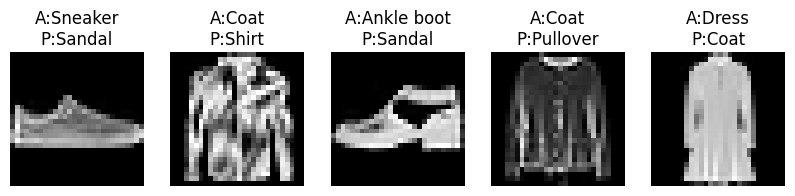

In [22]:
import matplotlib.pyplot as plt

class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.figure(figsize=(10,5))

for i in range(5):
    index = wrong_indices[i]

    plt.subplot(1,5,i+1)
    plt.imshow(x_test[index].reshape(28,28), cmap='gray')

    actual = class_names[y_true[index]]
    predicted = class_names[y_pred[index]]

    plt.title(f"A:{actual}\nP:{predicted}")
    plt.axis('off')

plt.show()

In [24]:
from tensorflow.keras.models import Model

# Select one test image
sample_image = x_test[0].reshape(1,28,28,1)

# Get convolution layer outputs
layer_outputs = [layer.output for layer in model2.layers if 'conv' in layer.name]

# Create feature extraction model
feature_model = Model(inputs=model2.inputs, outputs=layer_outputs)

# Generate feature maps
feature_maps = feature_model.predict(sample_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step


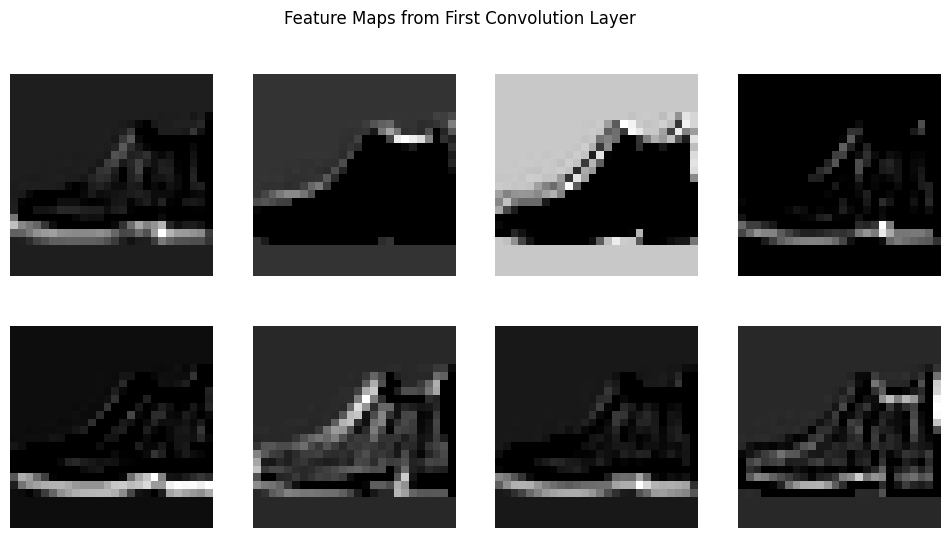

In [25]:
import matplotlib.pyplot as plt

feature_map = feature_maps[0]

plt.figure(figsize=(12,6))

for i in range(8):   # show first 8 filters
    plt.subplot(2,4,i+1)
    plt.imshow(feature_map[0,:,:,i], cmap='gray')
    plt.axis('off')

plt.suptitle("Feature Maps from First Convolution Layer")
plt.show()